# Text analytics for Business Insights: Develop a models using NLP frameworks such as spaCy, BERT, or RoBERTa for analyzing customer reviews/comments. Implement advanced text analytics techniques like Aspect-based Sentiment analysis, and Topic modelling using LDA or BERTopic

In [ ]:
import pandas as pd
import spacy
import re

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/SMA_DATASET/merged_comments.csv')

In [ ]:
nlp = spacy.load('en_core_web_sm')

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if not token.is_stop]
    return ' '.join(tokens)

df['Cleaned_Comment'] = df['Comment'].apply(clean_text)
print(df[['Comment', 'Cleaned_Comment']].head())

                                             Comment  \
0  I'm creating an infinite canvas that has all y...   
1  Man...If you built this for large mainframe co...   
2  On a smaller scale it reminds me of the origin...   
3  Cool. My long-term vision for software develop...   
4  Sometimes I daydream that we moved beyond text...   

                                     Cleaned_Comment  
0  m create infinite canvas organization code doc...  
1  manif build large mainframe codebase think out...  
2  small scale remind original concept light tabl...  
3  cool longterm vision software development new ...  
4  daydream move text file format uuid lineversio...  


In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.5 MB/s eta 0:00:00


Sentiment
positive    1388
neutral      476
negative     280
Name: count, dtype: int64


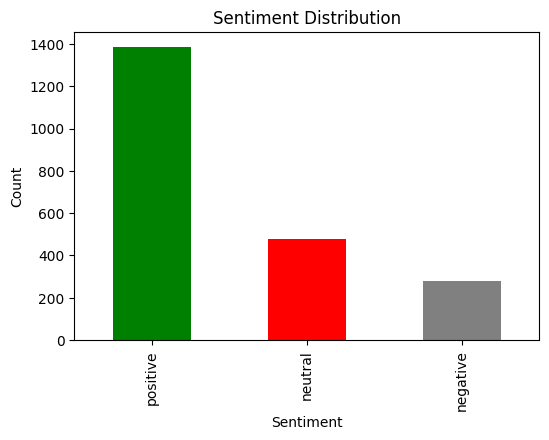

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Function to get sentiment score
def get_sentiment(text):
    sentiment = sia.polarity_scores(text)
    return 'positive' if sentiment['compound'] > 0.05 else 'negative' if sentiment['compound'] < -0.05 else 'neutral'

# Apply sentiment analysis
df['Sentiment'] = df['Cleaned_Comment'].apply(get_sentiment)

# Display sentiment counts
print(df['Sentiment'].value_counts())

# Plot sentiment distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df['Sentiment'].value_counts().plot(kind='bar', color=['green', 'red', 'gray'])
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Distribution')
plt.show()


In [ ]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 57.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [ ]:
from bertopic import BERTopic
import matplotlib.pyplot as plt

# Train BERTopic model
topic_model = BERTopic()
topics, probs = topic_model.fit_transform(df['Cleaned_Comment'])

# Add topics to DataFrame
df['Topic'] = topics

# Show top 10 topics
print(topic_model.get_topic_info().head(10))

# --- Visualization ---

# 1️⃣ *Bar Chart of Top Topics*
topic_model.visualize_barchart(top_n_topics=10)

# 2️⃣ *Topic Distribution*
topic_model.visualize_distribution(probs)

# 3️⃣ *Word Cloud for Topics*
topic_model.visualize_term_rank()

# 4️⃣ *Topic Similarity Heatmap*
topic_model.visualize_heatmap()

   Topic  Count                              Name  \
0     -1    349       -1_not_dreamweaver_app_work   
1      0     90            0_speed_drive_road_car   
2      1     66  1_language_parser_compiler_write   
3      2     58    2_video_language_learn_learner   
4      3     45            3_thank_hey_sorry_read   
5      4     42        4_serial_usb_port_hardware   
6      5     38       5_log_monitoring_set_vacuum   
7      6     37        6_code_canvas_figure_novel   
8      7     36             7_api_apis_agent_aiml   
9      8     36   8_ingredient_grocery_food_track   

                                      Representation  \
0  [not, dreamweaver, app, work, ve, use, bit, fr...   
1  [speed, drive, road, car, lane, people, limit,...   
2  [language, parser, compiler, write, zig, imple...   
3  [video, language, learn, learner, vocabulary, ...   
4  [thank, hey, sorry, read, thosereply, uareply,...   
5  [serial, usb, port, hardware, wasm, upse, insp...   
6  [log, monitoring, set